# 06 — scATAC-seq with ArchR

**Run on: x86** — Requires Cell Ranger ATAC output. Run `scripts/python/download_cellranger_data.py` on x86, then `scripts/python/run_cellranger.py` or `cellranger-atac count` -> fragments.tsv.gz.

**Target:** Figs 3I-O, 4A-N — Super-enhancers, Il1b peaks, accessibility

## Datasets

- Whole heart: TAC WT vs TAC Brd4KO
- CD45+ nuclei: Sham, TAC, TAC_Brd4KO

## Pipeline

1. Create ArchR project, add fragments
2. QC: minTSS 15-16, minFrags 1584-3163
3. addIterativeLSI -> Harmony -> clusters
4. Peak calling, DARs, super-enhancers

In [1]:
# Setup (R)
suppressPackageStartupMessages({
  library(ArchR)
  library(ggplot2)
})

# Keep notebook output compact
options(progressr.enable = FALSE)

addArchRThreads(threads = max(1, parallel::detectCores() %/% 2))
addArchRGenome("mm10")

out_base <- file.path("..", "output", "cellranger")

# CD45+ scATAC: one library per condition (Fig 4–style; matches ## Datasets)
runs_atac_min <- c(
  Sham = "SRR22882163",
  TAC_WT = "SRR22882164",
  TAC_Brd4KO = "SRR22882166"
)



                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
# Locate Cell Ranger ATAC fragments

find_fragments <- function(run_id, base_dir = out_base) {
  candidates <- c(
    file.path(base_dir, run_id, "outs", "fragments.tsv.gz"),
    file.path(base_dir, run_id, "outs", "atac_fragments.tsv.gz")
  )
  for (p in candidates) {
    if (file.exists(p)) return(p)
  }
  NA_character_
}

frag_paths <- vapply(unname(runs_atac_min), find_fragments, character(1))
frag_tbl <- data.frame(condition = names(runs_atac_min), run_id = unname(runs_atac_min), fragments = frag_paths)
print(frag_tbl)

if (all(is.na(frag_paths))) {
  stop(
    "No scATAC fragment files found under ", out_base, "\n\n",
    "Expected: output/cellranger/<SRR>/outs/fragments.tsv.gz\n",
    "Run (on x86): python scripts/python/run_cellranger.py --ref-atac data/refs/refdata-cellranger-arc-GRCm39-2024-A"
  )
}

frag_tbl <- frag_tbl[!is.na(frag_tbl$fragments), , drop = FALSE]


             condition      run_id
SRR22882163       Sham SRR22882163
SRR22882164     TAC_WT SRR22882164
SRR22882166 TAC_Brd4KO SRR22882166
                                                         fragments
SRR22882163 ../output/cellranger/SRR22882163/outs/fragments.tsv.gz
SRR22882164 ../output/cellranger/SRR22882164/outs/fragments.tsv.gz
SRR22882166 ../output/cellranger/SRR22882166/outs/fragments.tsv.gz


In [3]:
# Build Arrow files + ArchR project

arrow_files <- createArrowFiles(
  inputFiles = setNames(frag_tbl$fragments, frag_tbl$run_id),
  sampleNames = frag_tbl$run_id,
  minTSS = 15,
  minFrags = 1500,
  addTileMat = TRUE,
  addGeneScoreMat = TRUE,
  force = FALSE
)

# ArchR does not allow spaces in outputDirectory full path.
# Use a no-space working directory under /tmp and keep Arrow files in place.
proj_dir <- "/tmp/archr_proj_min"
dir.create(proj_dir, recursive = TRUE, showWarnings = FALSE)

proj <- ArchRProject(
  ArrowFiles = arrow_files,
  outputDirectory = proj_dir,
  copyArrows = FALSE
)

proj$condition <- frag_tbl$condition[match(proj$Sample, frag_tbl$run_id)]
proj


Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

ArchR logging to : ArchRLogs/ArchR-createArrows-175df5b96527e-Date-2026-03-31_Time-18-46-17.324482.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

subThreading Disabled since ArchRLocking is TRUE see `addArchRLocking`

2026-03-31 18:46:17.404835 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-createArrows-175df5b96527e-Date-2026-03-31_Time-18-46-17.324482.log

Using GeneAnnotation set by addArchRGenome(Mm10)!

Using GeneAnnotation set by addArchRGenome(Mm10)!

Validating Arrows...

Getting SampleNames...



R_zmq_msg_send errno: 4 strerror: Interrupted system call




Getting Cell Metadata...



R_zmq_msg_send errno: 4 strerror: Interrupted system call




Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        

class: ArchRProject 
outputDirectory: /tmp/archr_proj_min 
samples(3): SRR22882163 SRR22882164 SRR22882166
sampleColData names(1): ArrowFiles
cellColData names(14): Sample TSSEnrichment ... BlacklistRatio
  condition
numberOfCells(1): 49594
medianTSS(1): 26.496
medianFrags(1): 7146.5

1 
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the ArchR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the ArchR package.
  Please report the issue to the authors.”


1 


Picking joint bandwidth of 0.953

Picking joint bandwidth of 0.0651



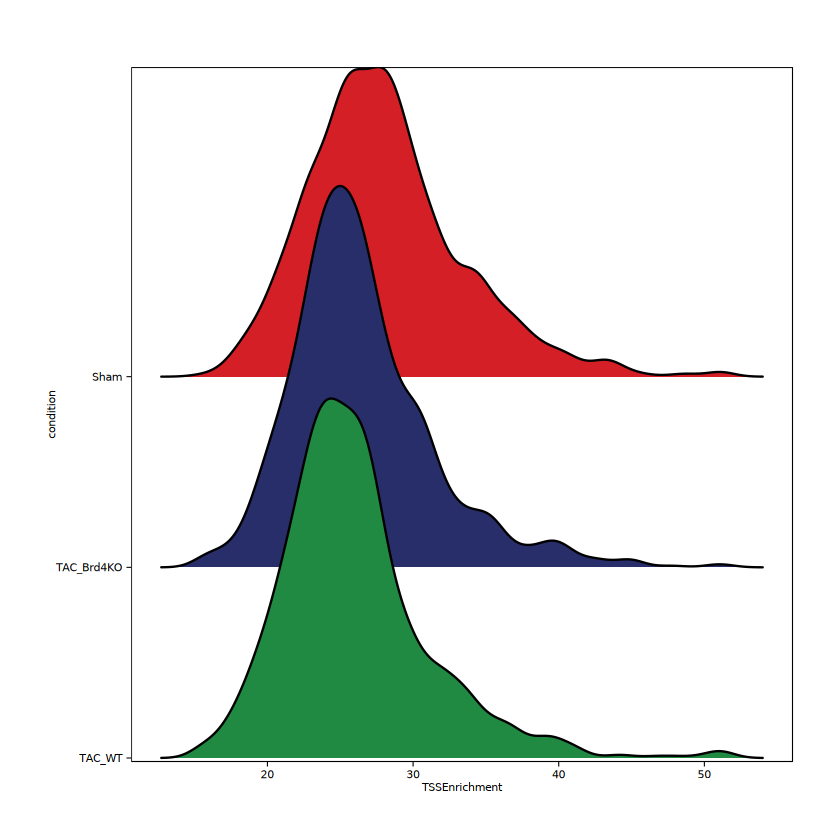

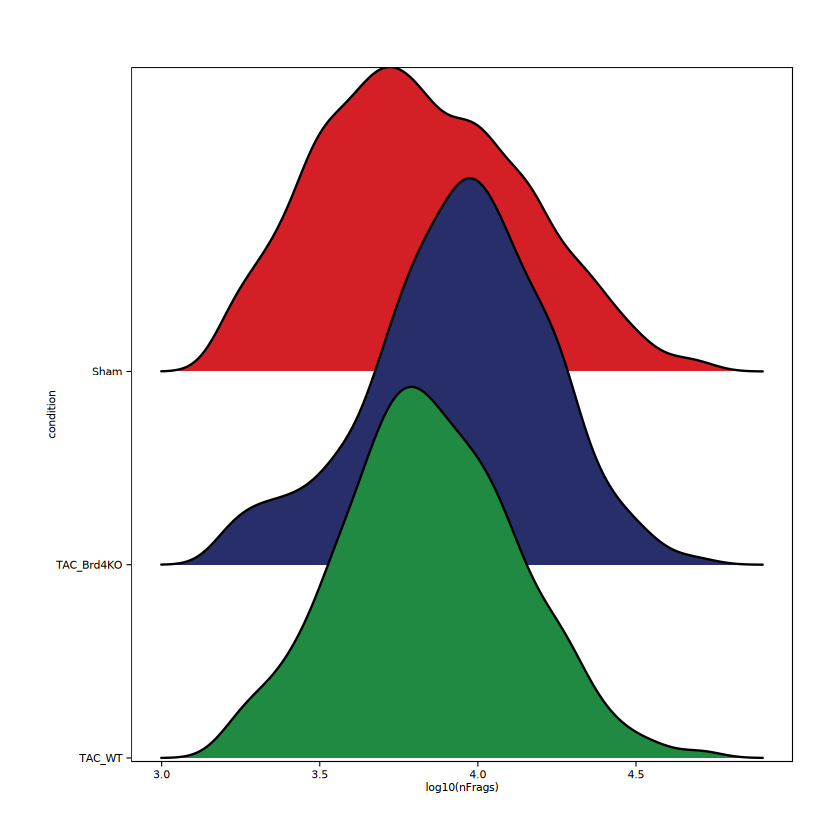

In [4]:
# QC visualization (TSS enrichment + fragments)

p_tss <- plotGroups(
  ArchRProj = proj,
  groupBy = "condition",
  colorBy = "cellColData",
  name = "TSSEnrichment"
)

p_frags <- plotGroups(
  ArchRProj = proj,
  groupBy = "condition",
  colorBy = "cellColData",
  name = "log10(nFrags)"
)

p_tss
p_frags


## Interpretation of scATAC QC plots

- Higher `TSSEnrichment` indicates cleaner chromatin accessibility signal around promoters, which generally reflects better nucleus quality.
- Higher `log10(nFrags)` reflects deeper per-cell coverage; very low-fragment cells are usually low-information and can destabilize downstream clustering.
- Compare condition distributions to check for strong technical imbalance before biological interpretation.
- Practical takeaway: proceed when all groups retain a broad high-quality core, while documenting any condition-specific QC skew.

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-175df325760eb-Date-2026-03-31_Time-18-46-19.411982.log
If there is an issue, please report to github with logFile!

2026-03-31 18:46:19.577069 : Computing Total Across All Features, 0.002 mins elapsed.

2026-03-31 18:46:22.089985 : Computing Top Features, 0.044 mins elapsed.

###########
2026-03-31 18:46:22.767212 : Running LSI (1 of 2) on Top Features, 0.055 mins elapsed.
###########

2026-03-31 18:46:22.8018 : Sampling Cells (N = 10001) for Estimated LSI, 0.055 mins elapsed.

2026-03-31 18:46:22.803209 : Creating Sampled Partial Matrix, 0.056 mins elapsed.

2026-03-31 18:46:38.120802 : Computing Estimated LSI (projectAll = FALSE), 0.311 mins elapsed.

Filtering 1 dims correlated > 0.75 to log10(depth + 1)

2026-03-31 18:46:51.643658 : Identifying Clusters, 0.536 mins elapsed.

2026-03-31 18:46:56.054816 : Identified 4 Clusters, 0.61 mins elapsed.

2026-03-31 18:46:56.062947 : Saving LSI Iteration, 0.61 mins elapse

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 49594
Number of edges: 1013398

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8330
Number of communities: 25
Elapsed time: 6 seconds


8 singletons identified. 17 final clusters.

2026-03-31 18:49:29.783937 : Testing Biased Clusters, 0.43 mins elapsed.

2026-03-31 18:49:30.209437 : Testing Outlier Clusters, 0.437 mins elapsed.

2026-03-31 18:49:30.212211 : Assigning Cluster Names to 17 Clusters, 0.437 mins elapsed.

2026-03-31 18:49:30.275337 : Finished addClusters, 0.438 mins elapsed.

18:49:30 UMAP embedding parameters a = 0.583 b = 1.334

18:49:30 Read 49594 rows and found 29 numeric columns

18:49:30 Using Annoy for neighbor search, n_neighbors = 30

18:49:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

18:49:32 Writing NN index file to temp file /tmp/RtmpjbG4R5/file175df64a0336b

18:49:32 Searching Annoy index using 10 threads, search_k = 3000

18:49:33 Annoy recall = 100%

18:49:34 Commencing

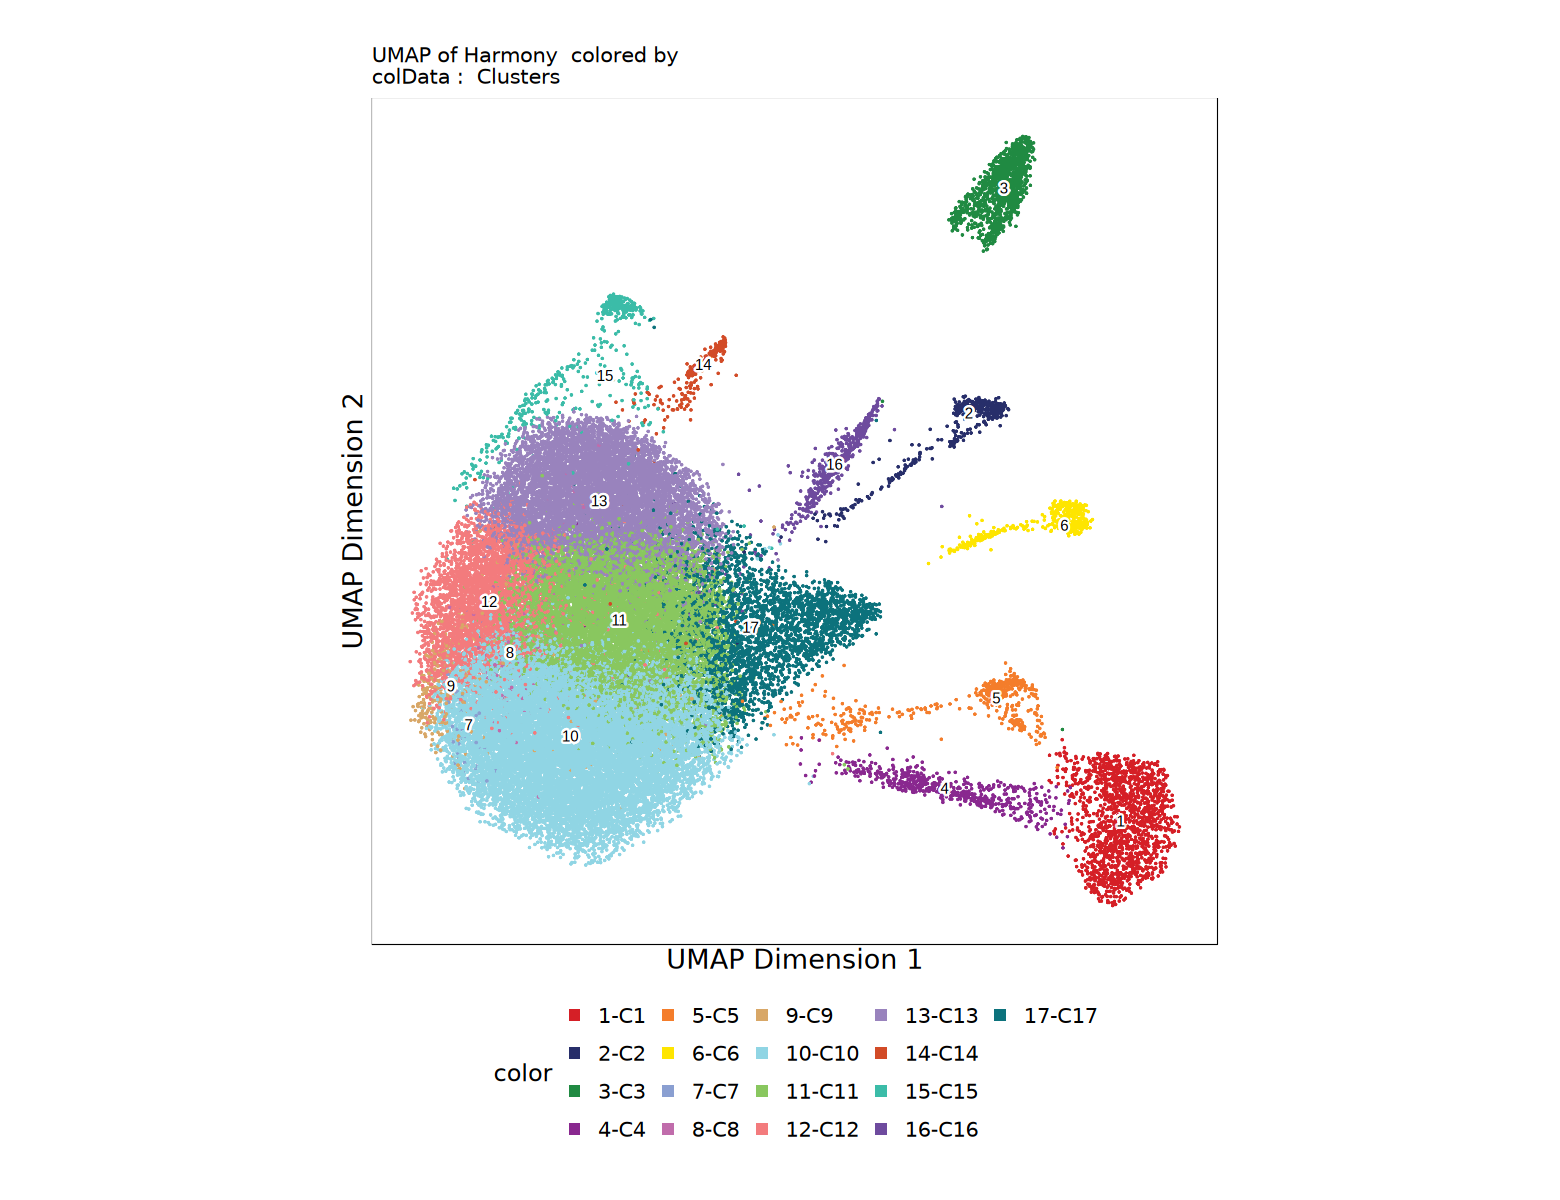

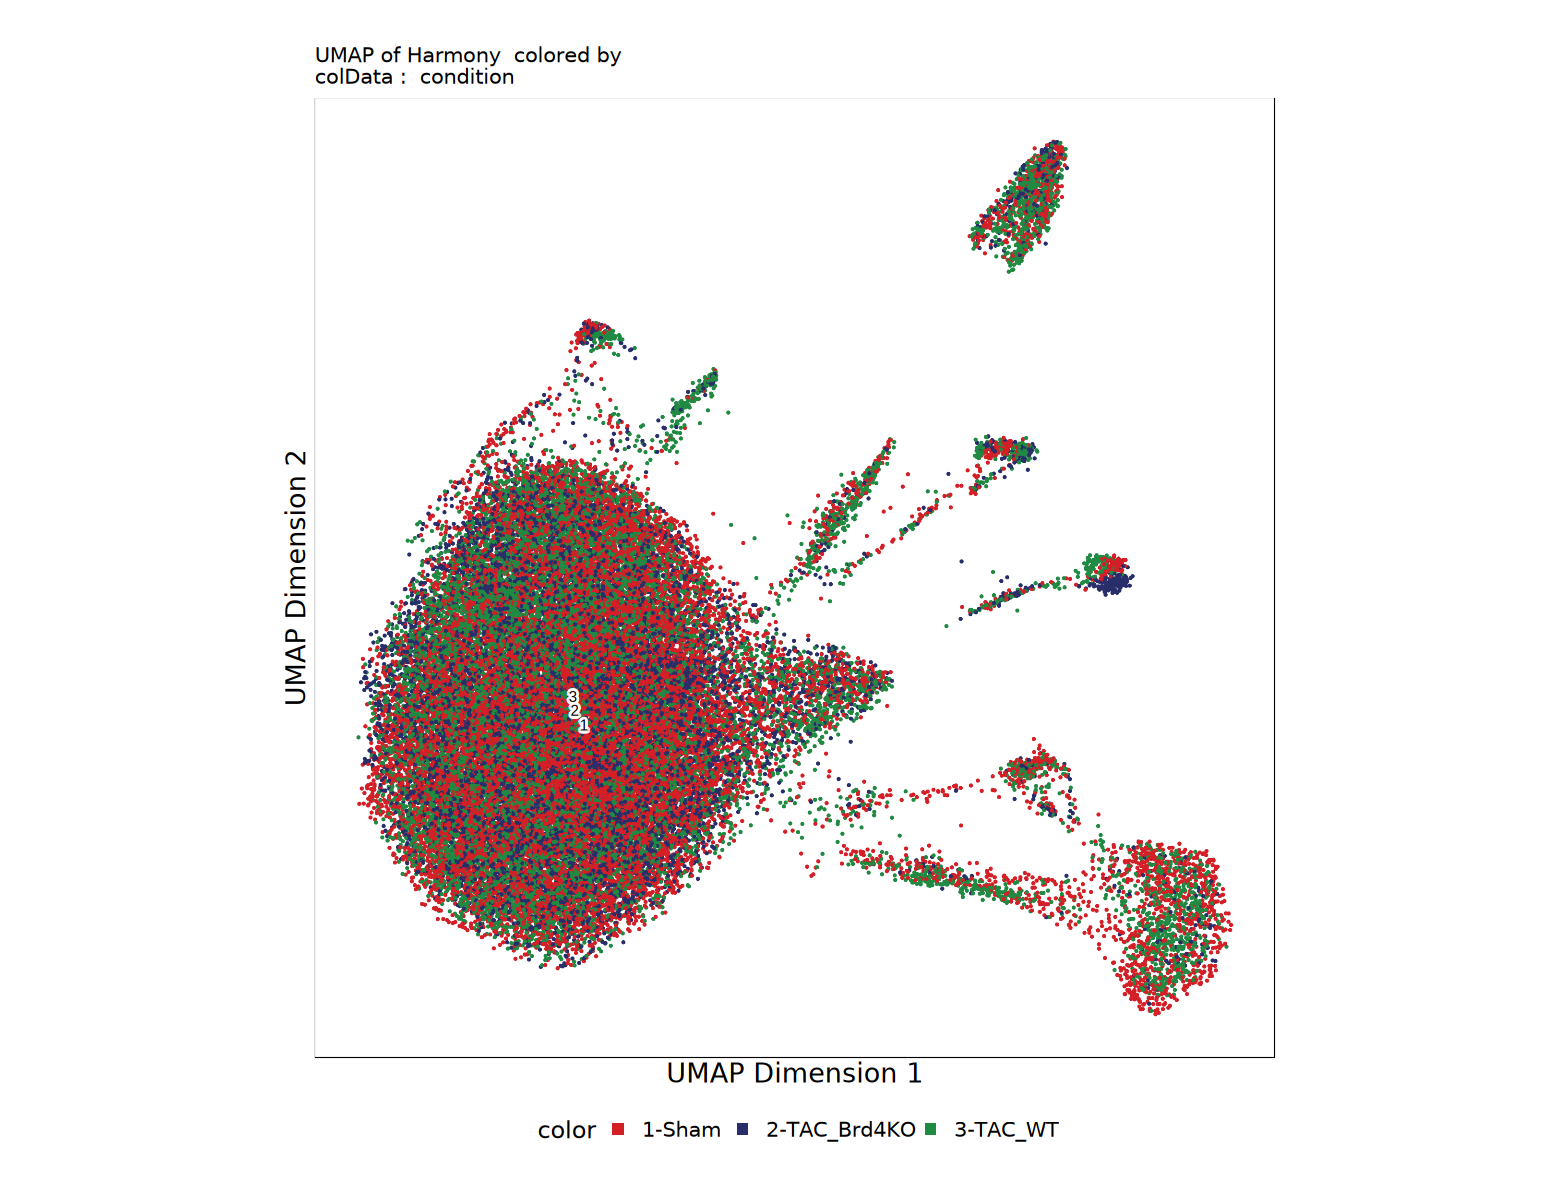

In [5]:
# Dimensionality reduction + clustering

proj <- addIterativeLSI(
  ArchRProj = proj,
  useMatrix = "TileMatrix",
  name = "IterativeLSI",
  iterations = 2,
  clusterParams = list(resolution = c(0.2), sampleCells = 5000, n.start = 10),
  varFeatures = 25000,
  dimsToUse = 1:30,
  force = TRUE
)

proj <- addHarmony(
  ArchRProj = proj,
  reducedDims = "IterativeLSI",
  name = "Harmony",
  groupBy = "condition",
  force = TRUE
)

proj <- addClusters(input = proj, reducedDims = "Harmony", name = "Clusters", resolution = 0.6, force = TRUE)
proj <- addUMAP(ArchRProj = proj, reducedDims = "Harmony", name = "UMAP", nNeighbors = 30, minDist = 0.5, metric = "cosine", force = TRUE)

# Make UMAP outputs larger for readability in notebook
options(repr.plot.width = 13, repr.plot.height = 10)

p_clusters <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "Clusters", embedding = "UMAP") +
  ggplot2::theme(
    text = ggplot2::element_text(size = 16),
    axis.title = ggplot2::element_text(size = 16),
    axis.text = ggplot2::element_text(size = 13),
    legend.title = ggplot2::element_text(size = 14),
    legend.text = ggplot2::element_text(size = 12)
  )

p_condition <- plotEmbedding(ArchRProj = proj, colorBy = "cellColData", name = "condition", embedding = "UMAP") +
  ggplot2::theme(
    text = ggplot2::element_text(size = 16),
    axis.title = ggplot2::element_text(size = 16),
    axis.text = ggplot2::element_text(size = 13),
    legend.title = ggplot2::element_text(size = 14),
    legend.text = ggplot2::element_text(size = 12)
  )

p_clusters
p_condition


## Interpretation of UMAP and condition overlays

- Distinct peripheral islands and a large central manifold indicate multiple separable chromatin states, with some states closely related and others clearly distinct.
- The condition overlay shows substantial cross-condition overlap in the central manifold, suggesting shared baseline immune chromatin programs across Sham, TAC_WT, and TAC_Brd4KO.
- Condition-skewed peripheral islands are present and are biologically interesting, but should be treated as hypothesis-generating until confirmed by DAR tests and replicate-aware composition statistics.
- Practical takeaway: annotate broad state groups from cluster structure first, then quantify condition effects with formal downstream tests (DAR/motif enrichment and per-cluster proportion testing).


In [6]:
# Optional downstream hooks (DAR + motifs)

# proj <- addGroupCoverages(proj, groupBy = "condition")
# proj <- addReproduciblePeakSet(proj, groupBy = "condition", pathToMacs2 = "macs2")
# proj <- addPeakMatrix(proj)
# markersPeaks <- getMarkerFeatures(
#   ArchRProj = proj,
#   useMatrix = "PeakMatrix",
#   groupBy = "condition",
#   bias = c("TSSEnrichment", "log10(nFrags)"),
#   testMethod = "wilcoxon"
# )
# markersPeaks


## Practical tips (Cell Ranger ATAC + ArchR)

- Ensure each selected run has `output/cellranger/<SRR>/outs/fragments.tsv.gz`.
- Start with a minimal subset for figure prototyping, then scale to all runs.
- If runtime is slow, reduce temporary cell count in LSI (`sampleCells`) and increase later.
- Treat initial cluster/condition shifts as hypothesis-generating until confirmed with DAR/motif evidence and biological replication.